In [2]:
import os

In [3]:
from kelly_utils import simulate_regime_vol_with_jumps, drawdown, MC_func, simulate_two_asset_returns, rebalanced_returns, stats, kelly_no_shorts
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# USER SETTINGS 

periods = 12
n_years = 30

burn_in = 1000

max_leverage = 10.0
min_leverage = 0.0

f = 0.75

Rebalancing = 12     # Times per year

scale_long = "none"  # options: "none", "same_avg_vol", "vol_targeting"

sharpe = "variable"  # options: "constant", "variable"

short_constraint = False

annual_ret_eq = 0.05 
annual_ret_b  = 0.02 

SR_eq = 0.40            # Expected annualized sharpe ratio.
SR_b  = 0.40            # Expected annualized sharpe ratio.

m  = 0.00            # degree of momentum

rho_r = 0.6

partial_vol = 0.4   # vol_eq / vol_b

# Parameters for volatility simulations

p_LL            = 0.999
p_HH            = 0.99
vol_low_annual  = 0.15
vol_high_annual = 0.40
rho             = 0.95
std_lns         = 0.05
jump_prob       = 0.5/periods
jump_size       = 0.30

In [5]:
N = n_years * periods
T = N + burn_in

p_eq = np.zeros(T)
p_b = np.zeros(T)
r_eq = np.zeros(T)
r_b = np.zeros(T)
E_r_eq = np.zeros(T)
E_r_b = np.zeros(T)

momentum_eq = np.zeros(T)
momentum_b = np.zeros(T)
c_eq = SR_eq /np.sqrt(periods)
c_b  = SR_b /np.sqrt(periods)

lns, regime, jumps = simulate_regime_vol_with_jumps(T, p_LL, p_HH, vol_low_annual, vol_high_annual, rho, std_lns, jump_prob, jump_size, periods)

vol = np.exp(lns)

In [6]:
p_eq, p_b, r_eq, r_b, E_r_eq, E_r_b, momentum_eq, momentum_b = simulate_two_asset_returns(
    periods=periods,
    T=T,
    lns=lns,
    regime=regime,
    p_eq=p_eq,
    p_b=p_b,
    sharpe= sharpe, 
    c_eq=c_eq,
    c_b=c_b,
    m=m,
    annual_ret_eq=annual_ret_eq,
    annual_ret_b=annual_ret_b,
    partial_vol=partial_vol,
    rho_r=rho_r
)

In [7]:
# Remove all burn-ins
p_eq = p_eq[burn_in:] - p_eq[burn_in]
p_b = p_b[burn_in:] - p_b[burn_in]
r_eq = r_eq[burn_in:]
r_b = r_b[burn_in:]
E_r_eq = E_r_eq[burn_in:]
E_r_b = E_r_b[burn_in:]
momentum_eq = momentum_eq[burn_in:]
momentum_b = momentum_b[burn_in:]
lns = lns[burn_in:]
regime = regime[burn_in:]
jumps = jumps[burn_in:]
vol = vol[burn_in:]

In [8]:
# Simple price, return and volatility
P_eq = np.exp(p_eq)
R_eq = np.exp(r_eq) - 1
P_b = np.exp(p_b)
R_b = np.exp(r_b) - 1

E_R_eq = E_r_eq + 0.5 * vol**2
E_R_b = E_r_b + 0.5 * (vol*partial_vol)**2
E_R2_eq = vol**2
E_R2_b = (vol*partial_vol)**2

In [9]:
w_test = np.zeros((N,2))
records = []


for i in range(N):
    E_R = np.array([E_R_eq[i], E_R_b[i]])
    cov = np.sqrt(E_R2_eq[i]) * rho_r * np.sqrt(E_R2_b[i])
    SIGMA = np.array([[E_R2_eq[i], cov],
                      [cov,      E_R2_b[i]]])
    if short_constraint:
        w_i = kelly_no_shorts(E_R, SIGMA)
    else: 
        w_i = np.linalg.inv(SIGMA) @ E_R
    w_test[i] = w_i

    # --- diagnostic logging ---
    var1, var2 = SIGMA[0,0], SIGMA[1,1]
    corr12     = SIGMA[0,1] / np.sqrt(var1 * var2)
    cond_num   = np.linalg.cond(SIGMA)
    records.append({
        'i':       i,
        'w1':      w_i[0],
        'w2':      w_i[1],
        'mu1':     E_R[0],
        'mu2':     E_R[1],
        'var1':    var1,
        'var2':    var2,
        'corr12':  corr12,
        'cond':    cond_num
    })

# after the loop, build a DataFrame
df = pd.DataFrame(records)

In [10]:
net_r_eq, tc_eq = rebalanced_returns(R = r_eq, w = df.w1*f, rebalancing = Rebalancing, periods = periods, tc = 0.001)
net_r_b, tc_b = rebalanced_returns(R = r_b, w = df.w2*f, rebalancing = Rebalancing, periods = periods, tc = 0.001)

Kelly_r = net_r_b + net_r_eq
Kelly_R = np.exp(Kelly_r) - 1


In [11]:
EW_wealth = (p_eq + p_b)/2
Kelly_wealth = np.cumsum(Kelly_r)

In [12]:
Kelly_sharpe = stats(Kelly_R, Rebalancing)[0]
Kelly_FinalW = stats(Kelly_R, Rebalancing)[1]
Kelly_maxDD = stats(Kelly_R, Rebalancing)[2]



In [13]:
Kelly_sharpe

np.float64(0.33319161130582137)

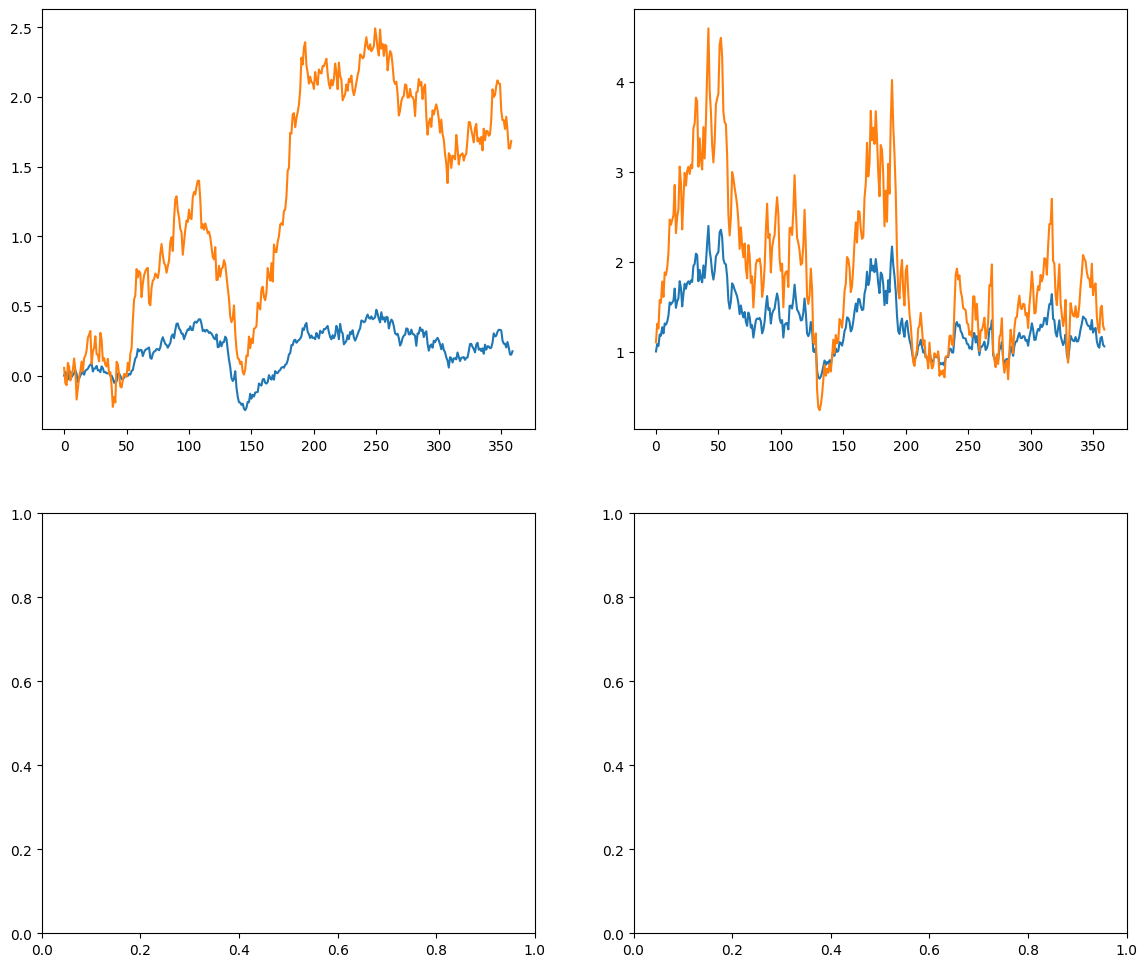

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

axs[0,0].plot(EW_wealth)
axs[0,0].plot(Kelly_wealth)

axs[0,1].plot(df.w1*f)
axs[0,1].plot(df.w2*f)